In [1]:
import numpy as np
import pandas as pd
import glob, os, vcf, warnings, shutil, subprocess, re, sys
from Bio import Seq, SeqIO
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import scipy, pysam
from matplotlib.colors import ListedColormap
from collections import Counter
from matplotlib.patches import Patch

sys.path.append("scripts")
from epi_utils import *

h37Rv_path = "/n/data1/hms/dbmi/farhat/Sanjana/H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))
h37Rv_regions = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_v4.csv"))

h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv"))
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

TRUST_dir = "/home/sak0914/TRUST_data_processing"

df_culture_Illumina_WGS = pd.read_csv(f"{TRUST_dir}/processed_data/combined_patient_WGS_data.csv")

df_RedCap = pd.read_csv(f"{TRUST_dir}/raw_data/TRUST_DATA_2025-05-12_1129.cleaned.wide.csv")
df_RedCap.pid.nunique()

458

In [23]:
df_image_tracking = pd.read_excel("~/TRUST_data_processing/data_curation/TRUST_CXR_Images_tracking.xlsx", sheet_name=None)['Sheet 1']
print(len(df_image_tracking))

# df_image_tracking = df_image_tracking.dropna(subset='Name').drop_duplicates(['Name', 'notes', 'Path']).reset_index(drop=True)
# print(len(df_image_tracking))

2011


In [19]:
df_image_tracking.iloc[df_image_tracking.index.values[df_image_tracking.duplicated(subset=['Name', 'notes'], keep=False)]].sort_values(['Name', 'notes'])

,pid,redcap_repeat_instance,Name,Modified,Modified By,Item Type,Path,redcap_event_name,redcap_repeat_instrument,cxr_dicom_add,notes,in_redcap
262,T0131,1.0,T0131_1A.dcm,45379.490602,"Thomson, Sarah",Item,teams/TRUSTResearchTeam/Shared Documents/Gener...,chest_radiograph_arm_1,chest_radiograph,1.0,baseline,1.0
263,T0131,1.0,T0131_1A.dcm,45754.504039,"Quintero, Renzo",Item,teams/TRUSTResearchTeam/Shared Documents/Gener...,chest_radiograph_arm_1,chest_radiograph,1.0,baseline,1.0
260,T0131,1.0,T0131_1B.dcm,45754.504306,"Quintero, Renzo",Item,teams/TRUSTResearchTeam/Shared Documents/Gener...,chest_radiograph_arm_1,chest_radiograph,1.0,baseline,1.0
261,T0131,1.0,T0131_1B.dcm,45379.498958,"Thomson, Sarah",Item,teams/TRUSTResearchTeam/Shared Documents/Gener...,chest_radiograph_arm_1,chest_radiograph,1.0,baseline,1.0
326,T0161,2.0,T0161_2A.dcm,45379.498924,"Thomson, Sarah",Item,teams/TRUSTResearchTeam/Shared Documents/Gener...,chest_radiograph_arm_1,chest_radiograph,1.0,follow up,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1975,T0474,2.0,T0474_2B.dcm,45754.518310,"Quintero, Renzo",Item,teams/TRUSTResearchTeam/Shared Documents/Gener...,chest_radiograph_arm_1,chest_radiograph,1.0,follow up,1.0
1983,T0476,1.0,T0476_1A.dcm,45450.429606,Rebecca E. Hoffman,Item,teams/TRUSTResearchTeam/Shared Documents/Gener...,chest_radiograph_arm_1,chest_radiograph,1.0,baseline,1.0
1986,T0476,1.0,T0476_1A.dcm,45754.538021,"Quintero, Renzo",Item,teams/TRUSTResearchTeam/Shared Documents/Gener...,chest_radiograph_arm_1,chest_radiograph,1.0,baseline,1.0
1984,T0476,1.0,T0476_1B.dcm,45450.429699,Rebecca E. Hoffman,Item,teams/TRUSTResearchTeam/Shared Documents/Gener...,chest_radiograph_arm_1,chest_radiograph,1.0,baseline,1.0


In [26]:
df_image_tracking.query("Name=='T0131_1A.dcm'")

,pid,redcap_repeat_instance,Name,Modified,Modified By,Item Type,Path,redcap_event_name,redcap_repeat_instrument,cxr_dicom_add,notes,in_redcap
264,T0131,1.0,T0131_1A.dcm,45379.490602,"Thomson, Sarah",Item,teams/TRUSTResearchTeam/Shared Documents/Gener...,chest_radiograph_arm_1,chest_radiograph,1.0,baseline,1.0
265,T0131,1.0,T0131_1A.dcm,45754.504039,"Quintero, Renzo",Item,teams/TRUSTResearchTeam/Shared Documents/Gener...,chest_radiograph_arm_1,chest_radiograph,1.0,baseline,1.0


In [131]:
df_CXR_pred = pd.read_csv(f"{TRUST_dir}/processed_data/CXR_predictions.csv").query("Status=='Normal' & Time=='BL'")

# looked at these manually
df_CXR_pred.loc[df_CXR_pred['patientID_view']=='T0395_1B', 'view'] = '1C'
df_CXR_pred.loc[df_CXR_pred['patientID_view'].isin(['T0128_1C', 'T0137_1C', 'T0043_1C', 'T0134_1C']), 'view'] = '1B'

pids_no_PA = set(df_CXR_pred.query("view.str.contains('C')").pid) - set(df_CXR_pred.query("view.str.contains('B')").pid)
print(f"{len(pids_no_PA)} pids don't have a PA view but have an AP view")

df_CXR_pred = pd.concat([df_CXR_pred.query("view.str.contains('|'.join(['B', 'D', 'E']))"),
                         df_CXR_pred.query("pid in @pids_no_PA")
                        ])

# T0025_1B_2 is truncated. T0025_1B seems fine
df_CXR_pred = df_CXR_pred.query("patientID_view != 'T0025_1B_2'")

df_CXR_pred['Diff'] = df_CXR_pred.groupby('pid')['predicted_PLI'].transform(lambda x: np.max(x) - np.min(x))

df_CXR_pred['Study'] = 'TRUST'
print(df_CXR_pred.pid.nunique())

0 pids don't have a PA view but have an AP view
419


In [132]:
df_CXR_pred.query("Diff > 5").sort_values('pid')

,patientID_view,predicted_PLI,predicted_Timika,Filename,Status,pid,view,Time,Diff,Study
193,T0101_1D,28.043283,34.083473,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0101,1D,BL,5.040157,TRUST
194,T0101_1E,33.083440,39.006794,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0101,1E,BL,5.040157,TRUST


In [133]:
TOTAL_CXR = pd.read_csv("~/TOTAL_CXR_pred.csv").query("Status=='Normal' & Time=='BL'")

# H0055_1C is a PA view
TOTAL_CXR.loc[TOTAL_CXR['patientID_view']=='H0055_1C', 'view'] = '1B'

pids_no_PA = set(TOTAL_CXR.query("view.str.contains('C')").pid) - set(TOTAL_CXR.query("view.str.contains('B')").pid)
print(f"{len(pids_no_PA)} pids don't have a PA view but have an AP view")

# the two AP view look okay, so keep them to retain patients
TOTAL_CXR = pd.concat([TOTAL_CXR.query("view.str.contains('|'.join(['B', 'D', 'E']))"),
                         TOTAL_CXR.query("pid in @pids_no_PA")
                        ])

# P0695_1B_2 is truncated, so keep P0695_1B_1
TOTAL_CXR = TOTAL_CXR.query("patientID_view != 'P0695_1B_2'")

# H0053_1B_1 and H0053_1B_2 look the same to me, so just keep the first. But also the difference is only 5.5 pp
TOTAL_CXR['Diff'] = TOTAL_CXR.groupby('pid')['predicted_PLI'].transform(lambda x: np.max(x) - np.min(x))

TOTAL_CXR['Study'] = 'TOTAL'

print(TOTAL_CXR.pid.nunique())

2 pids don't have a PA view but have an AP view
204


In [135]:
TOTAL_CXR.query("pid in @pids_no_PA")

,patientID_view,predicted_PLI,predicted_Timika,Filename,Status,pid,view,Time,Diff,Study
130,H0007_1C,20.360353,25.267488,/n/data1/hms/dbmi/farhat/rollingDB/TOTAL/CXR/d...,Normal,H0007,1C,BL,0.0,TOTAL
258,H0069_1C,37.011024,49.361145,/n/data1/hms/dbmi/farhat/rollingDB/TOTAL/CXR/d...,Normal,H0069,1C,BL,0.0,TOTAL


In [136]:
TOTAL_CXR.query("Diff > 5").sort_values('pid')

,patientID_view,predicted_PLI,predicted_Timika,Filename,Status,pid,view,Time,Diff,Study
224,H0053_1B_1,25.911770,27.218088,/n/data1/hms/dbmi/farhat/rollingDB/TOTAL/CXR/d...,Normal,H0053,1B_1,BL,5.476673,TOTAL
225,H0053_1B_2,31.388443,32.901940,/n/data1/hms/dbmi/farhat/rollingDB/TOTAL/CXR/d...,Normal,H0053,1B_2,BL,5.476673,TOTAL


In [154]:
df_send = pd.concat([df_CXR_pred.sort_values('patientID_view').drop_duplicates(subset='pid', keep='first'),
                     TOTAL_CXR.sort_values('patientID_view').drop_duplicates(subset='pid', keep='first')
                    ])

del df_send['Diff']

len(df_send), df_send.pid.nunique()

(623, 623)

In [155]:
df_send.to_csv("~/CXR_combined.csv", index=False)

In [149]:
df_send.Status.value_counts()

Status
Normal    623
Name: count, dtype: int64

In [151]:
df_send.view.value_counts()

view
1B        617
1C          2
1B_1        2
1D          1
1B_new      1
Name: count, dtype: int64

In [156]:
df_send.Time.value_counts()

Time
BL    623
Name: count, dtype: int64

In [158]:
df_send.predicted_PLI.min(), df_send.predicted_PLI.max()

(1.8553994, 77.53317)

# Associating F2 from Direct from Sputum Sequencing with TCC

## 1. Keep baseline samples for each pid

In [2]:
Brendon_DS = pd.read_excel(f"{TRUST_dir}/processed_data/Brendon_DS_Redcap_04112025.xlsx", sheet_name=None)

if len(Brendon_DS.keys()) == 1:
    Brendon_DS = Brendon_DS[list(Brendon_DS.keys())[0]]
        
# # require that they had high enough coverage and a lineage assignment
# Brendon_DS = Brendon_DS.dropna(subset='DS_mix_phylotypes').query("Median_cov >= 10").reset_index(drop=True)

Brendon_DS['Sample_ID'] = Brendon_DS['Sample_ID'].str.replace('_', '-').str.replace('M', 'm')

print(f"{sum(pd.isnull(Brendon_DS['DS_F2']))}/{len(Brendon_DS)} samples do not have F2")
print(f"{Brendon_DS.PID.nunique()} pids")

44/210 samples do not have F2
176 pids


In [7]:
Brendon_DS.query("PID=='T0224'")

,PID,Sample_ID,Sequencing Lims_K_designation,MFS_ID,DS_sample_category,DS_sample_subcategory,CultureConvert_class,Twist_version,DNA_concentration_ngul,Total DNA,...,≥ 10X,DS_F2,DS_mix_phylotypes,DS_mix_props,DS_lineage_catagory,Cult_mix_phylotypes,Cult_mix_props,Cult_lineage_category,Paired_category,Notes
78,T0224,S0224-01,NaN,MFS-133,Baseline,Baseline,Avg_Del_Cx,V1,1.27,31.75,...,99.3,0.049069,"2.2.M4.4,2.2.M1.1","0.4892,0.5108",Mixed,"2.2.M4.4,2.2.M1.1","0.9889,0.0111",Mixed,Reduced Diversity In Culture,NaN


In [21]:
Brendon_DS.query("PID=='T0364'")

,PID,Sample_ID,Sequencing Lims_K_designation,MFS_ID,DS_sample_category,DS_sample_subcategory,CultureConvert_class,Twist_version,DNA_concentration_ngul,Total DNA,...,≥ 10X,DS_F2,DS_mix_phylotypes,DS_mix_props,DS_lineage_catagory,Cult_mix_phylotypes,Cult_mix_props,Cult_lineage_category,Paired_category,Notes


In [20]:
Brendon_DS.query("PID in ['T0010', 'T0066', 'T0072', 'T0087', 'T0116', 'T0152', 'T0198', 'T0267', 'T0305', 'T0311', 'T0322', 'T0364', 'T0367', 'T0393', 'T0427', 'T0441', 'T0444', 'T0457']").sort_values('PID')

,PID,Sample_ID,Sequencing Lims_K_designation,MFS_ID,DS_sample_category,DS_sample_subcategory,CultureConvert_class,Twist_version,DNA_concentration_ngul,Total DNA,...,≥ 10X,DS_F2,DS_mix_phylotypes,DS_mix_props,DS_lineage_catagory,Cult_mix_phylotypes,Cult_mix_props,Cult_lineage_category,Paired_category,Notes
20,T0066,S0066-01,NaN,MFS-39,Baseline,Baseline,Avg_Del_Cx,V1,0.21,5.250,...,99.9,0.238054,"2.2.M4.4,4.3,2.2.M1.1","0.4751,0.1081,0.4168",Mixed,"2.2.M1.1,4.3","0.9207,0.0793",Mixed,Partially Concordant Mix,Share a major lineage but not down to sub lineage
104,T0267,S0267-01,K0647540,MFS-270,Baseline,Re_enrolled,Avg_Del_Cx,V2,1.31,32.750,...,0.0,NaN,NaN,NaN,NaN,"2.2.M1.1,4.3","0.793,0.207",Mixed,Unknown,NaN
134,T0305,S0305-01,NaN,MFS-313,Baseline,Baseline,Avg_Del_Cx,V2,4.8,120.000,...,99.3,0.136918,4.3,1,single_lineage,"4.3,2.2.M1.1","0.5746,0.4254",Mixed,Reduced Diversity In Sputum,NaN
142,T0322,S0322-01,NaN,MFS-198,Baseline,Baseline,Rapid_Cx,V2,0.059,1.475,...,99.9,0.264358,"4.1.1.3,2.2.M1.1,4.9","0.8282,0.0483,0.1235",Mixed,"4.1.1.3,2.2.M1.1,4.9","0.9366,0.0191,0.0443",Mixed,Complete Concordance Mix,NaN
143,T0322,S0322-01B,K0647400,MFS-198,Baseline_B,B_samples,Rapid_Cx,V2,6.51,162.750,...,99.9,0.443260,"2.2.M1.1,4.1.1.3,4.9","0.674,0.2724,0.0536",Mixed,"4.1.1.3,2.2.M1.1,4.9","0.9366,0.0191,0.0443",Mixed,Complete Concordance Mix,NaN
173,T0367,S0367-01,NaN,MFS-456,Baseline,Baseline,Avg_Del_Cx,V2,93,2325.000,...,99.7,0.367381,"2.2.M1.1,3.5.1","0.6035,0.3965",Mixed,"2.2.M1.1,3.5.1,4","0.9112,0.0482,0.0406",Mixed,Partially Concordant Mix,Low frequency L4 markers. Might be concordant ...
174,T0367,S0367-01B,K0647170,MFS-456,Baseline_B,B_samples,Avg_Del_Cx,V2,10.9,272.500,...,99.7,0.031709,"3.5.1,2.2.M1.1","0.8071,0.1929",Mixed,"2.2.M1.1,3.5.1,4","0.9112,0.0482,0.0406",Mixed,Partially Concordant Mix,Low frequency L4 markers. Might be concordant ...
185,T0393,S0393-01,NaN,MFS-485,Baseline,Baseline,Avg_Del_Cx,V2,120,3000.000,...,99.7,0.492658,"4.1.1.3,2.2.M1.1","0.4779,0.5221",Mixed,"2.2.M1.1,4.1.1.3,4.9","0.9286,0.0255,0.0459",Mixed,Partially Concordant Mix,Low frequency L4 markers. Might be concordant ...
186,T0393,S0393-01B,K0647320,MFS-485,Baseline_B,B_samples,Avg_Del_Cx,V2,14,350.000,...,99.4,0.046499,4.3.3,1,single_lineage,"2.2.M1.1,4.1.1.3,4.9","0.9286,0.0255,0.0459",Mixed,Partially Concordant Mix,Low frequency L4 markers. Might be concordant ...


In [16]:
df_mapping = pd.read_excel("freschi_tbtyper_mapping.xlsx", sheet_name=None)['tbtyper_to_freschi']

In [17]:
df_mapping.query("tbtyper_lineage in ['2.2.M4.4', '2.2.M1.1']")

,tbtyper_lineage,freschi_lineage,freq,n
25,2.2.M1.1,2.2.1.1.1,1.0,46
38,2.2.M4.4,2.2.1.1.1,1.0,4


In [4]:
Brendon_DS_with_lineage_results = Brendon_DS.dropna(subset='DS_mix_phylotypes').reset_index(drop=True)

# have to add .astype(str) because if the lineage is a single value, like "4", then it might be float type
Brendon_DS_with_lineage_results['DS_num_lineages'] = Brendon_DS_with_lineage_results['DS_mix_phylotypes'].astype(str).str.split(',').apply(len)

In [5]:
Brendon_DS_with_lineage_results.DS_num_lineages.value_counts()

DS_num_lineages
1    69
3    59
2    39
Name: count, dtype: int64

In [345]:
Brendon_DS_with_lineage_results.query("DS_F2 > 0.2 & DS_lineage_catagory=='single_lineage'")[['Sample_ID', 'Sequencing Lims_K_designation', 'DS_sample_subcategory', 'DS_F2', 'DS_mix_phylotypes', 'DS_mix_props']]

,Sample_ID,Sequencing Lims_K_designation,DS_sample_subcategory,DS_F2,DS_mix_phylotypes,DS_mix_props
32,S0143_01,NaN,Baseline,0.299181,4.3,1
36,S0161_01,NaN,Baseline,0.247841,4,1
41,S0171_01,NaN,Baseline,0.248441,4.3,1
83,S0258_01,NaN,Baseline,0.328134,4.3,1
98,S0279_01,K0647450,Resequenced,0.226586,4.3,1
99,S0279_01,NaN,Baseline,0.215332,4.3,1
107,S0291_09,NaN,Followup,0.451736,4.1.2,1
117,S0326_01B,K0647130,B_samples,0.261391,4.8.1,1
118,S0329_01,NaN,Baseline,0.304734,4.3,1
125,S0340_01,K0647490,Re_enrolled + Household,0.429661,4,1


In [473]:
FASTQ_files = glob.glob("/n/data1/hms/dbmi/farhat/fastq_db/TRUST_Directsputum/*/*.fastq.gz")
len(FASTQ_files)

448

In [285]:
keep_FASTQ_files = [fName for fName in FASTQ_files if 'halfreaction' not in fName]
len(keep_FASTQ_files)

432

In [298]:
other_name_mapping = Brendon_DS[['Sample_ID', 'Sequencing Lims_K_designation']].dropna(subset='Sequencing Lims_K_designation')
other_name_mapping['Sequencing Lims_K_designation'] = other_name_mapping['Sequencing Lims_K_designation'].str[:-1]

other_name_mapping = dict(zip(other_name_mapping['Sequencing Lims_K_designation'], other_name_mapping['Sample_ID']))

In [299]:
df_FASTQ = pd.DataFrame(columns = ['Sample_ID', 'Original_ID', 'fName'])

for i, fName in enumerate(keep_FASTQ_files):
    
    sample_ID = os.path.basename(fName).split('_')[0]
    
    suffix = os.path.basename(fName).split('_', 2)[-1].split('_')[0].split('.fastq.gz')[0]
    
    pattern = re.compile(r"S[0-9]{4}_[A-Za-z0-9]{2,3}(?=_)")
    match = re.findall(pattern, fName)
    
    if len(match) > 0:
        assert len(match) == 1
        df_FASTQ.loc[i, :] = [match[0], match[0], fName]
    else:
        pattern = re.compile(r"S[0-9]{4}-[A-Za-z0-9]{2,3}(?=_)")
        match = re.findall(pattern, fName)
        
        if len(match) > 0:
            assert len(match) == 1
            df_FASTQ.loc[i, :] = [match[0], match[0], fName]
        else:
            if sample_ID in other_name_mapping.keys():
                new_sample_ID = other_name_mapping[sample_ID]
                df_FASTQ.loc[i, :] = [f"{new_sample_ID}+{sample_ID}", new_sample_ID, fName]
            # else:
            #     if 'K064760' in fName:
            #         print(sample_ID)
            
df_FASTQ['Sample_ID'] = df_FASTQ['Sample_ID'].str.replace('_', '-').str.replace('+', '_')
df_FASTQ['Original_ID'] = df_FASTQ['Original_ID'].str.replace('_', '-')

df_FASTQ['R1'] = df_FASTQ['fName'].str.contains('R1').astype(int)

len(df_FASTQ)

420

In [300]:
samples_multiple_FQ = pd.DataFrame(df_FASTQ.groupby('Original_ID')['fName'].count()).query("fName != 2").index.values
len(samples_multiple_FQ)

5

In [330]:
df_FASTQ.query("Original_ID in @samples_multiple_FQ")

,Sample_ID,Original_ID,fName,R1
202,S0279-01,S0279-01,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_Direct...,1
203,S0279-01,S0279-01,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_Direct...,0
204,S0279-06,S0279-06,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_Direct...,1
205,S0279-06,S0279-06,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_Direct...,0
240,S0331-01,S0331-01,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_Direct...,1
241,S0331-01,S0331-01,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_Direct...,0
274,S0377-01,S0377-01,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_Direct...,1
275,S0377-01,S0377-01,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_Direct...,0
298,S0416-01,S0416-01,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_Direct...,1
299,S0416-01,S0416-01,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_Direct...,0


In [301]:
# Brendon_DS.query("Sample_ID in @samples_multiple_FQ").sort_values(['Sample_ID', 'Sequencing Lims_K_designation'], na_position='first')

In [318]:
df2 = (
    df_FASTQ
    .assign(Read=df_FASTQ["fName"].str.contains("R1").map({True: "R1", False: "R2"}))
    .pivot(index="Sample_ID", columns="Read", values="fName")
    .reset_index()
)

df2 = df2.merge(df_FASTQ[['Sample_ID', 'Original_ID']].drop_duplicates())

In [319]:
len(df2), len(df_FASTQ)

(210, 420)

In [322]:
for i, row in df2.iterrows():
    original_ID = row['Original_ID']
    
    if row['Sample_ID'] != original_ID and len(df2.query("Original_ID==@original_ID")) > 1:
        df2.loc[i, 'Output_ID'] = row['Sample_ID']
    else:
        df2.loc[i, 'Output_ID'] = original_ID

In [327]:
df2.set_index(['Original_ID', 'Sample_ID', 'Output_ID']).to_csv("~/MtbLongitudinalDiversity/direct_sputum/sample_FASTQ_mapping.csv")

In [346]:
df2.to_csv("~/MtbLongitudinalDiversity/direct_sputum/sample_FASTQ_mapping.csv")

In [33]:
sample = 'S0219-01'
df_minor_alleles = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/TRUST_directSputum/{sample}/lineage/minor_allele_fractions.csv").sort_values("maf", ascending=False).reset_index(drop=True)

fastlin_output = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/TRUST_directSputum/{sample}/fastlin/output.txt", sep='\t')
fastlin_separate_output = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/TRUST_directSputum/{sample}/fastlin/separate_output.txt", sep='\t')

In [34]:
fastlin_output

,#sample,data_type,k_cov,mixture,lineages,log_barcodes,log_errors
0,S0219-01,paired,766,yes,"4.1.1 (5), 4.4.1 (5), 2.2.1.1 (4), 3.1.1 (427)...","2 (181, 219, 175, 212, 276, 187, 238, 206, 208...",NaN


In [35]:
fastlin_separate_output

,#sample,data_type,k_cov,mixture,lineages,log_barcodes,log_errors
0,S0219-01.R1.kraken.filtered,single,383,yes,"3.1.1 (220), 2.2.1 (100), 4.3.2.1 (15)","2 (111, 94, 106, 92, 89, 141, 107, 116, 97, 10...",NaN
1,S0219-01.R2.kraken.filtered,single,383,yes,"3.1.1 (213), 2.2.1 (96), 4.3.2.1 (15)","2 (108, 93, 100, 85, 86, 135, 101, 122, 84, 10...",NaN


In [45]:
def get_all_higher_lineages(lineage_str):
    '''
    This function returns a list of all higher level lineages for a given lineage. 
    
    For example, if you pass in 4.3.2.1, it will return ['4', '4.3', '4.3.2', '4.3.2.1']
    '''
    
    lineage_split_str = lineage_str.split('.')

    # this also returns the lineage itself
    return ['.'.join(lineage_split_str[:i+1]) for i in range(len(lineage_split_str))]



# def get_top_N_distinct_lineages(df_allele_fractions, num_mixed_lineages):

#     df_allele_fractions = df_allele_fractions.sort_values("maf", ascending=False).reset_index(drop=True)
    
#     # keep track of the lineages with the most mixed SNPs. the top lineage will be the first one.
#     top_N_lineages = [df_allele_fractions['lineage'].values[0]]
    
#     while len(top_N_lineages) < num_mixed_lineages:
        
#         for i, row in df_allele_fractions.iterrows():
            
#             lineage_str = row['lineage']
            
#             # get a list of all higher level lineages because we need to check if the lineage is a subset of a lineage that's already in top_N_lineages
#             query_lineages = get_all_higher_lineages(row['lineage'])
            
#             # get all the higher order lineages of all lineages in top_N_lineages. use itertools.chain.from_iterable to flatten the list of lists
#             target_lineages = itertools.chain.from_iterable([get_all_higher_lineages(lineage) for lineage in top_N_lineages])

#             # check no overlap, then the query lineage is distinct from what's already in top_N_lineages
#             if len(set(query_lineages).intersection(target_lineages)) == 0:

#                 top_N_lineages.append(row['lineage'])

#     return top_N_lineages

def get_lineage_defining_SNP_depths(reduced_VCF):

	'''
	This function takes as input, the path to the reduced VCF file, then extracts SINGLE base calls from
	the VCF file generated by Pilon specified as a lineage defining SNP from Coll et. al. 2014. 
	The function returns a DataFrame for a single isolate that contains base calling information
	for all of these SNP positions.
	'''

	#path to VCF file
	VCF_file = reduced_VCF

	vcf_reader = vcf.Reader(open(VCF_file , 'r'))

	#create dictionaries to store information for each call
	lineage_dict = {}
	position_dict = {}
	depth_dict = {}
	max_base_count_dict = {}

	#indexer for dataframe containing lineage defining SNPs
	index = 0

	#iterate through each record from VCF file
	for record in vcf_reader:

		#check to see that the record does not correspond to a variant call that is a Structural Variant (SVTYPE)
		if 'SVTYPE' not in record.INFO.keys():

			#position of variant on the Reference Genome
			reference_position = record.POS 

			#reference allele
			ref_allele = record.REF

			#alternate alleles (if there are any)
			alt_alleles = record.ALT

			#check to see if call is at a lineage defining site AND that call is a SNP
			if ( reference_position in list( lineage_defining_SNPs.position ) ) and check_call_is_SNP(ref_allele , alt_alleles):

				######## Retrieve Relevant information for filtering quality of Base Call ########
				# Mean Base Quality @ locus
				BQ = record.INFO['BQ']

				# Mean Mapping Quality @ locus
				MQ = record.INFO['MQ']

				# Number of Reads w/ Deletion 
				DC = record.INFO['DC']

				# Number of Reads w/ Insertion
				IC = record.INFO['IC']  
				
				# Depth of Valid Reads in Pileup
				VD = record.INFO['DP']

				### Filtering Criteria
				#---> Mean Base Quality > 20
				#---> Mean Mapping Quality > 30
				#---> No Reads Supporting Insertions
				#---> No Reads Supporting Deletions
				#---> Number of High Quality Reads >= 25
				if (BQ > 20) and (MQ > 30) and (DC == 0) and (IC == 0) and (VD >= 25): #SNP passed filtering criteria!

					# Valid read depth; some reads may have been filtered
					total_depth = record.INFO['DP']

					#Count of As, Cs, Gs, Ts at locus
					base_counts = record.INFO['BC']

					#most common base - depth
					most_common_base_depth = np.max(base_counts)

					#lineage that is defined by SNP
					lineage_defined = list( lineage_defining_SNPs[lineage_defining_SNPs.position == reference_position].lineage )[0]

					#After filtering for high-quality lineage-defining calls, store all of the pertinent information about the Base Call
					lineage_dict[index] = lineage_defined
					position_dict[index] = reference_position
					depth_dict[index] = total_depth
					max_base_count_dict[index] = most_common_base_depth

					index += 1

	#convert dictionaries to series
	lineage = pd.Series(lineage_dict)
	position = pd.Series(position_dict)
	depth = pd.Series(depth_dict)
	max_base_count = pd.Series(max_base_count_dict)

	#create DataFrame to hold all lineage defining SNPs
	lineage_SNP_depths_from_sample_DF = pd.DataFrame()
	lineage_SNP_depths_from_sample_DF['lineage'] = lineage
	lineage_SNP_depths_from_sample_DF['position'] = position
	lineage_SNP_depths_from_sample_DF['depth'] = depth
	lineage_SNP_depths_from_sample_DF['max_base_count'] = max_base_count

	#calculate the minor depth for each SNP site
	lineage_SNP_depths_from_sample_DF['minor_depth'] = lineage_SNP_depths_from_sample_DF['depth'] - lineage_SNP_depths_from_sample_DF['max_base_count']

	return lineage_SNP_depths_from_sample_DF


def check_call_is_SNP(ref_allele , alt_alleles):
	
	'''This function checks to see if Call is a SNP and not an InDel or Structural Variant'''
	
	#check that Reference Allele is 1 base
	if len(ref_allele) == 1:
		
		#check to see if there is no alternate allele
		if alt_alleles == [None]:
			
			good_SNP = True
			
		#if there is an alternate allele(s) check to see that they are all just 1 base
		elif ( sum( [(len(alt_allele) == 1) for alt_allele in alt_alleles] ) == len(alt_alleles) ):
			
			good_SNP = True
			
		#at least 1 alternate allele was longer than 1 base
		else:
			
			good_SNP = False
	
	#reference allele was longer than 1 base        
	else:
		good_SNP = False
			
	return good_SNP

In [47]:
lineage_defining_SNPs_file = "/home/sak0914/Mtb_Megapipe/references/phylogeny/Coll2014_SNPs_all.csv"

# Lineage Defining SNPs - Import full set of Lineage Defining SNP sets from Coll et. al. 2014
lineage_defining_SNPs = pd.read_csv(lineage_defining_SNPs_file).rename(columns={"#lineage": "lineage"})
lineage_defining_SNPs['lineage'] = [val.replace('lineage', '') for val in lineage_defining_SNPs['lineage'].values]

# According to Wyllie et. al. 2018, drop SNP sets corresponding to branches with fewer than 20 SNPs
# excluded_branches = ['1.2' , '3.1' , '3.1.2' , '4.1.2' , '4.3.4.2.1' , '4.6' , '4.7']
exclude_branch_SNP_thresh = 20

# use lineage as the counts column too, so the index and the column have the same name
excluded_branches = pd.DataFrame(lineage_defining_SNPs.groupby('lineage')['lineage'].count()).query("lineage < @exclude_branch_SNP_thresh").index.values
# print(f"Excluding lineages {excluded_branches} with fewer than {exclude_branch_SNP_thresh} SNPs defining them")
full_length = len(lineage_defining_SNPs)

lineage_defining_SNPs = lineage_defining_SNPs.query("lineage not in @excluded_branches").reset_index(drop=True)
# print(f"Keeping {len(lineage_defining_SNPs)}/{full_length} lineage-defining SNPs from the Coll 2014 scheme")

reduced_VCF = os.path.join(f"/n/data1/hms/dbmi/farhat/Sanjana/TRUST_directSputum/{sample}", "lineage", f"{sample}_lineage_positions.vcf")

lineage_SNP_depths_from_sample_df = get_lineage_defining_SNP_depths(reduced_VCF)

In [48]:
top_N_lineages

['3.1.1', '2', '4']

In [60]:
Brendon_DS_with_lineage_results.query("DS_num_lineages > 2").query("Sample_ID=='S0219_01'")[['Sample_ID', 'DS_mix_phylotypes', 'DS_mix_props']]

,Sample_ID,DS_mix_phylotypes,DS_mix_props
64,S0219_01,"3.1.1.1,2.2.M4.4,4.3","0.7375,0.2011,0.0614"


In [51]:
fastlin_separate_output

,#sample,data_type,k_cov,mixture,lineages,log_barcodes,log_errors
0,S0219-01.R1.kraken.filtered,single,383,yes,"3.1.1 (220), 2.2.1 (100), 4.3.2.1 (15)","2 (111, 94, 106, 92, 89, 141, 107, 116, 97, 10...",NaN
1,S0219-01.R2.kraken.filtered,single,383,yes,"3.1.1 (213), 2.2.1 (96), 4.3.2.1 (15)","2 (108, 93, 100, 85, 86, 135, 101, 122, 84, 10...",NaN


In [56]:
100/335, 96/(213+96+15)

(0.29850746268656714, 0.2962962962962963)

In [55]:
220/335, 213/(213+96+15)

(0.6567164179104478, 0.6574074074074074)

In [62]:
num_mixed_lineages = 3

# keep track of the lineages with the most mixed SNPs. the top lineage will be the first one.
top_N_lineages = [df_minor_alleles['lineage'].values[0]]

for i, row in df_minor_alleles.iterrows():
    
    if len(top_N_lineages) < num_mixed_lineages:

        lineage_str = row['lineage']

        # get a list of all higher level lineages because we need to check if the lineage is a subset of a lineage that's already in top_N_lineages
        query_lineages = get_all_higher_lineages(row['lineage'])

        # get all the higher order lineages of all lineages in top_N_lineages. use itertools.chain.from_iterable to flatten the list of lists
        target_lineages = itertools.chain.from_iterable([get_all_higher_lineages(lineage) for lineage in top_N_lineages])

        # check no overlap, then the query lineage is distinct from what's already in top_N_lineages
        if len(set(query_lineages).intersection(target_lineages)) == 0:

            top_N_lineages.append(row['lineage'])
         
# calculate FN measure from the depths at lineage defining sites
M = lineage_SNP_depths_from_sample_df.query("lineage in @top_N_lineages")['minor_depth'].sum()
D = lineage_SNP_depths_from_sample_df.query("lineage in @top_N_lineages")['depth'].sum()

FN = M / D

print(FN)

0.21517897239466385


In [46]:
df_culture_Illumina_WGS.query("Original_ID in @samples_more_than_2_lineages")[['Original_ID', 'F2', 'Coll2014']].sort_values('F2')

,Original_ID,F2,Coll2014
440,S0403-01,0.003829,4.4.1.1
741,S0242-01,0.005826,4.4.1.1
428,S0330-01,0.006105,4.1.1.1
298,S0019-01,0.006151,4.3.3
797,S0280-01,0.006909,4.3.4.2.1
292,S0008-01,0.007025,4.1.1.1
27,S0157-01,0.007799,4.4.1.1
506,S0377-01,0.008630,4.1.1.1
604,S0049-01,0.008670,4.1.1.1
746,S0255-01,0.008836,4.1.1.1


In [198]:
Brendon_DS[['PID', 'DS_F2', 'DS_mix_phylotypes', 'DS_mix_props', 'DS_lineage_catagory']].query("DS_lineage_catagory=='single_lineage'").sort_values('DS_F2', ascending=False)

,PID,DS_F2,DS_mix_phylotypes,DS_mix_props,DS_lineage_catagory
166,T0435,0.449777,4,1,single_lineage
133,T0340,0.429661,4,1,single_lineage
136,T0348,0.424834,4,1,single_lineage
95,T0258,0.328134,4.3,1,single_lineage
127,T0329,0.304734,4.3,1,single_lineage
39,T0143,0.299181,4.3,1,single_lineage
48,T0171,0.248441,4.3,1,single_lineage
43,T0161,0.247841,4,1,single_lineage
108,T0279,0.226586,4.3,1,single_lineage
103,T0272,0.178560,2.2.M1.4,1,single_lineage


In [234]:
# Brendon_DS = pd.read_excel(f"{TRUST_dir}/processed_data/Brendon_DS_Redcap_04112025.xlsx", sheet_name=None)

# if len(Brendon_DS.keys()) == 1:
#     Brendon_DS = Brendon_DS[list(Brendon_DS.keys())[0]]

# Brendon_DS['Sample_ID'] = Brendon_DS['Sample_ID'].str.replace('_', '-').str.replace('M', 'm')

# print(f"{sum(pd.isnull(Brendon_DS['DS_F2']))}/{len(Brendon_DS)} samples do not have F2")

# # exclude the B samples and keep only the first sample
# Brendon_DS['Sample_Week'] = Brendon_DS['Sample_ID'].str.split('-').str[-1].str.replace('B', '').str.replace('m5', '20').astype(int)
# # print(Brendon_DS.Sample_Week.value_counts())

# Brendon_DS = Brendon_DS.query("~Sample_ID.str.contains('B') & Sample_Week == 1").reset_index(drop=True)

# Brendon_DS = Brendon_DS.sort_values(['PID', 'Sample_Week']).drop_duplicates(subset='PID', keep='first')

# print(f"{Brendon_DS.PID.nunique()} pids")

def read_in_tbtyper_results(fName, min_prop=0.01):
    
    df_tbtyper_results = pd.read_csv(fName)
    
    for i, row in df_tbtyper_results.iterrows():
        
        lineages = row['mix_phylotypes'].split(',')
        lineage_props = row['mix_props'].split(',')
        
        lineage_prop_dict = dict(zip(lineages, lineage_props))
        
        del_lineages = []
        
        for lineage, prop in lineage_prop_dict.items():
            
            if float(prop) < min_prop:
                del_lineages.append(lineage)
                
        if len(del_lineages) > 0:
            for lineage in del_lineages:
                del lineage_prop_dict[lineage]
                
        new_lineages = list(lineage_prop_dict.keys())
        new_props = list(lineage_prop_dict.values())
        
        # if len(new_lineages) < len(lineages):
        #     print(row['Original_ID'])
                
        df_tbtyper_results.loc[i, ['mix_phylotypes', 'mix_props', 'n_phy']] = [','.join(new_lineages), ','.join(new_props), len(new_lineages)]
        
    df_tbtyper_results.loc[df_tbtyper_results['n_phy']==1, 'mix_props'] = '1'
        
    return df_tbtyper_results

df_tbtyper_results = read_in_tbtyper_results("~/MtbLongitudinalDiversity/direct_sputum/TBTypeR_full_results_matched_culture_DS.csv", min_prop=0.01).query("Sampling_Week <= 3")

assert len(df_tbtyper_results) == df_tbtyper_results.pid.nunique()
print(f"{df_tbtyper_results.pid.nunique()} pids")

132 pids


In [235]:
df_tbtyper_results.n_phy.value_counts()

n_phy
3.0    72
1.0    42
2.0    18
Name: count, dtype: int64

In [8]:
# Brendon_DS_for_model = Brendon_DS[['PID', 'DS_lineage_catagory', 'DS_F2', 'DS_mix_props']].rename(columns={'PID': 'pid'}).merge(df_RedCap.drop_duplicates(subset='pid'), on='pid')

# Brendon_DS_for_model['DS_mixed_lineage'] = (Brendon_DS_for_model['DS_lineage_catagory'] == 'Mixed').astype(int)
# Brendon_DS_for_model.loc[Brendon_DS_for_model['DS_lineage_catagory'] == 'Unknown', 'DS_mixed_lineage'] = np.nan

# Brendon_DS_for_model = Brendon_DS_for_model.dropna(subset='DS_mix_props')
# Brendon_DS_for_model['DS_mix_props'] = Brendon_DS_for_model['DS_mix_props'].astype(str)

# print(f"{Brendon_DS_for_model.pid.nunique()} pids")

In [198]:
def compute_shannon_entropy_mix_props(mix_prop_string):
    
    mix_props = np.array(mix_prop_string.split(',')).astype(float)
    
    return - np.sum(mix_props * np.log2(mix_props))

In [216]:
# Brendon_DS_for_model['DS_mix_props_Shannon_entropy'] = Brendon_DS_for_model['DS_mix_props'].apply(compute_shannon_entropy_mix_props)
# Brendon_DS_for_model['DS_num_lineages'] = Brendon_DS_for_model['DS_mix_props'].str.split(',').apply(len)

df_tbtyper_results['DS_mix_props_Shannon_entropy'] = df_tbtyper_results['mix_props'].apply(compute_shannon_entropy_mix_props)
df_tbtyper_results['DS_mixed_lineage'] = (df_tbtyper_results['n_phy'] > 1).astype(int)

df_tbtyper_results.n_phy.value_counts()
# print(f"Number of called lineages is {Brendon_DS_for_model.DS_num_lineages.min()}-{Brendon_DS_for_model.DS_num_lineages.max()}")

n_phy
1.0    59
2.0    42
3.0    31
Name: count, dtype: int64

In [217]:
df_tbtyper_results.DS_mixed_lineage.value_counts()

DS_mixed_lineage
1    73
0    59
Name: count, dtype: int64

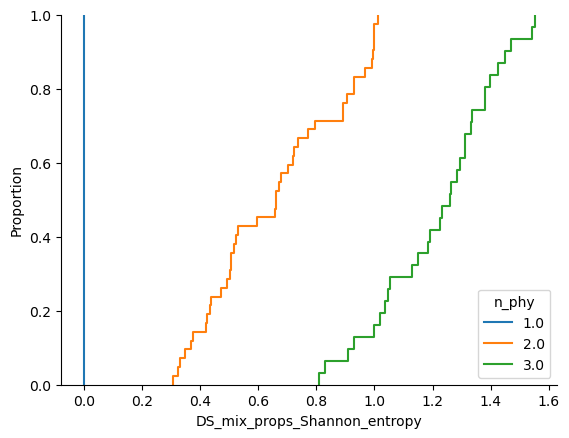

In [218]:
sns.ecdfplot(data=df_tbtyper_results,
             x='DS_mix_props_Shannon_entropy',
             hue='n_phy',
             palette='tab10'
            )

sns.despine()
plt.show()

# 2. Compute TCC on all available pids and then on the imputed datasets

```bash
# prepare data
python3 ~/TRUST_data_processing/scripts/prep_data_for_culture_imputation.py -i ~/TRUST_data_processing/raw_data/TRUST_DATA_2025-05-12_1129.cleaned.wide.csv -o ~/TRUST_data_processing/imputation

# run mice imputation in R

# compute TCC on the imputed cultures
python3 ~/TRUST_data_processing/scripts/compute_TCC_imputations.py -o ~/TRUST_data_processing/imputation
``` 

In [169]:
df_TCC = pd.read_csv(f"{TRUST_dir}/imputation/TCC.csv").query("pid in @df_tbtyper_results.pid")
df_TCC['delayed_TCC'] = (df_TCC['TCC'] > 8).astype(int)

df_cultures = pd.read_csv(f"{TRUST_dir}/imputation/combined_culture_results.csv").query("pid in @df_tbtyper_results.pid")

df_imputed_TCC = pd.read_csv(f"{TRUST_dir}/imputation/TCC_30_imputations.csv").query("pid in @df_tbtyper_results.pid")
df_imputed_TCC['delayed_TCC'] = (df_imputed_TCC['TCC'] > 8).astype(int)

DS_pids_with_valid_TCC = df_tbtyper_results.query("pid in @df_imputed_TCC.pid").pid.unique()
print(f"{len(DS_pids_with_valid_TCC)}/{df_tbtyper_results.pid.nunique()} DS pids have valid TCC")

df_tbtyper_results_with_TCC = df_tbtyper_results.query("Sampling_Week <= 2").merge(df_imputed_TCC.query("imp_num==0")[['pid', 'delayed_TCC', 'TCC']], on='pid')

124/132 DS pids have valid TCC


In [26]:
df_tbtyper_results_with_TCC.pid.nunique()

124

In [51]:
st.spearmanr(df_tbtyper_results_with_TCC['DS_mix_props_Shannon_entropy'],
             df_tbtyper_results_with_TCC['TCC'],
            )

SignificanceResult(statistic=-0.15484529885085466, pvalue=0.08594365034540717)

In [33]:
df_tbtyper_results_with_TCC.groupby('delayed_TCC')['DS_mix_props_Shannon_entropy'].mean()

delayed_TCC
0    0.601339
1    0.499419
Name: DS_mix_props_Shannon_entropy, dtype: float64

In [ ]:
# Create a contingency table
contingency_table = pd.crosstab(Brendon_DS_for_model_with_TCC['DS_mixed_lineage'], Brendon_DS_for_model_with_TCC['delayed_TCC'])
# print(contingency_table)

# Run chi-squared test
chi2, p, dof, expected = st.chi2_contingency(contingency_table)

# print(f"Chi-squared statistic = {chi2:.4f}")
# print(f"Degrees of freedom = {dof}")
print(f"P-value = {p:.4g}")
# print("Expected counts:")
# print(expected)

P-value = 1


In [ ]:
contingency_table

delayed_TCC,0,1
DS_mixed_lineage,,
0.0,40,37
1.0,40,38


In [187]:
contingency_table.sum()

delayed_TCC
0    80
1    75
dtype: int64

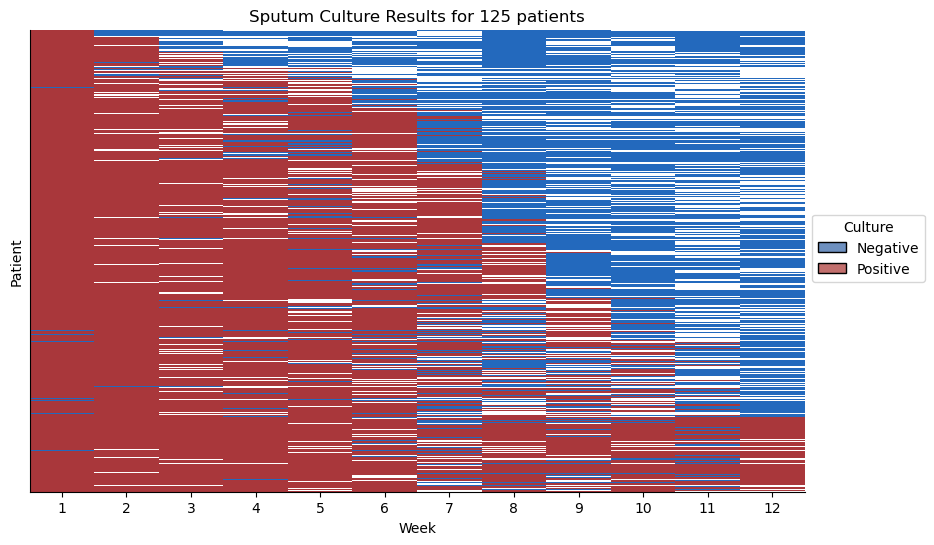

In [35]:
cultures_for_heatmap = df_cultures.query("sample_num <= 12 & pid in @df_imputed_TCC.pid").pivot(index='pid', columns='sample_num', values='result')

# same thing done before computing TCC and running imputation
cultures_for_heatmap = cultures_for_heatmap.replace('tb_positive_contaminated', 'tb_positive').replace('tb_negative_contaminated', np.nan).replace('tb_positive', 1).replace('tb_negative', 0)
cultures_for_heatmap.shape

fig, ax = plt.subplots(figsize=(10, 6))

# sort the patients by the number of positive cultures they have, increasing
# sort_lst = pd.DataFrame(cultures_for_heatmap.sum(axis=1)).sort_values(0).index.values

sort_lst = df_imputed_TCC.query("pid in @cultures_for_heatmap.index.values").sort_values(['TCC'], ascending=[True])['pid'].values

cultures_for_heatmap = cultures_for_heatmap.loc[sort_lst]

sns.heatmap(cultures_for_heatmap, cmap='vlag', cbar=False)

ax.set_yticks([])

plt.ylabel('Patient')
plt.xlabel('Week')

# Create a custom legend
legend_elements = [
    Patch(facecolor=sns.color_palette("vlag").as_hex()[0], edgecolor='black', label='Negative'),
    Patch(facecolor=sns.color_palette("vlag").as_hex()[-1], edgecolor='black', label='Positive')
]

ax.legend(
    handles=legend_elements, 
    title='Culture', 
    loc='upper left', 
    bbox_to_anchor=(1.01, 0.6),  # Adjust the position
    borderaxespad=0
)

plt.title(f"Sputum Culture Results for {cultures_for_heatmap.index.nunique()} patients")
sns.despine()
plt.savefig(f"{TRUST_dir}/figures/sputum_heatmap.svg", bbox_inches='tight')

## KM Estimate

In [36]:
median_survival_imputations = {}

# Prepare a list to collect survival functions from each imputation
survival_curves = []

# Fit Kaplan-Meier for each imputation and store survival function
for imp in df_imputed_TCC['imp_num'].unique():
    
    if imp > 0:
        imputed_data = df_imputed_TCC.query("imp_num==@imp")

        kmf = lifelines.KaplanMeierFitter()
        kmf.fit(durations=imputed_data['TCC'], event_observed=imputed_data['culture_convert'])

        survival_curves.append(kmf.survival_function_.rename(columns={"KM_estimate": f"imp_{imp}"}))

        median_survival_imputations[imp] = kmf.median_survival_time_

# Combine all imputed survival functions into one DataFrame
df_survival = pd.concat(survival_curves, axis=1)

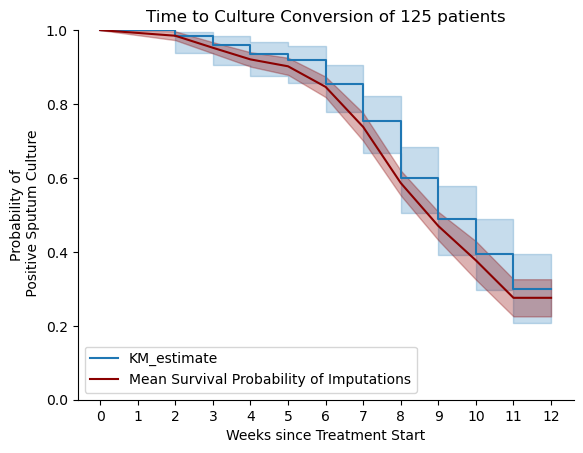

In [37]:
df_TCC = df_TCC.query("pid in @df_imputed_TCC.pid")

kmf_full_dataset = lifelines.KaplanMeierFitter()
kmf_full_dataset.fit(df_TCC['TCC'], event_observed=df_TCC['culture_convert'])

fig, ax = plt.subplots()

kmf_full_dataset.plot_survival_function()#show_censors=True, censor_styles={"marker": "+", "ms": 8, "mew": 0.5})
plt.ylim(0, 1)

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, df_imputed_TCC.TCC.max() + 1))

mean_survival = df_survival.mean(axis=1)
sd_survival = df_survival.std(axis=1)

# plot the mean survival probability at each week across the imputations
# plt.step(df_survival.index, mean_survival, label='KM Estimate of Imputed Datasets', where='post')
plt.plot(df_survival.index, mean_survival, label='Mean Survival Probability of Imputations', color='darkred')#, where='post')

# Calculate and plot the confidence interval using 1.96 * std for ~95% CI
ci_upper = mean_survival + 1.96 * sd_survival
ci_lower = mean_survival - 1.96 * sd_survival

# 'tab:blue'
plt.fill_between(df_survival.index, ci_lower, ci_upper, alpha=0.3, color='darkred')#, label='95% CI')

plt.title(f"Time to Culture Conversion of {df_imputed_TCC.pid.nunique()} patients")
plt.ylabel("Probability of\n Positive Sputum Culture") #
plt.xlabel("Weeks since Treatment Start")

plt.gca().get_legend().remove()
plt.legend()

sns.despine()
plt.savefig(f"{TRUST_dir}/figures/TCC_KM_estimate.svg", bbox_inches='tight')

## 3. Fit TCC models

### a. Univariate

### b. Multivariate

In [219]:
cols_lst = [
            'screen_sex',
            'screen_years',
            'underweight',
            'fstrom1_baseline', # smoking yes or no
            'smoked_substance_use',
            'peth_value_baseline',
            'HIV_CD4',
            'bl_prevtb',
            'TTP_baseline',
            'smear_pos_no_contam_sputum_specimen_1', # binary variable for smear positivity at baseline
            'diabetes',
            'high_lung_involvement',
            # 'DS_mix_props_Shannon_entropy', #'DS_F2',
            'DS_mixed_lineage',
            # 'inh_resistant',
           ]

patient_data = pd.read_csv(f"{TRUST_dir}/processed_data/20251126_cleaned_patient_outcomes_data.csv")
patient_data['underweight'] = (patient_data['bl_bmi'] < 18).astype(int)

# patient_data = patient_data.merge(Brendon_DS_for_model[['pid', 'DS_mix_props_Shannon_entropy', 'DS_F2', 'DS_mixed_lineage', 'DS_lineage_catagory']])
# patient_data = patient_data.merge(df_tbtyper_results_with_TCC[['pid', 'n_phy', 'DS_mix_props_Shannon_entropy', 'DS_mixed_lineage']])
patient_data = patient_data.merge(df_tbtyper_results[['pid', 'n_phy', 'DS_mix_props_Shannon_entropy', 'DS_mixed_lineage']])

# if patient_data.DS_mixed_lineage.mean() > 0.5:
#     patient_data['DS_unmixed_lineage'] = 1 - patient_data['DS_mixed_lineage']
#     cols_lst.append('DS_unmixed_lineage')
#     cols_lst.remove('DS_mixed_lineage')
    
# df_CXR_pred = pd.read_csv(f"{TRUST_dir}/processed_data/CXR_predictions.csv").query("Status=='Normal' & Time=='BL'").reset_index(drop=True)

# # keep only the first instance of each one
# df_CXR_pred = df_CXR_pred.sort_values(['pid', 'patientID_view']).drop_duplicates(subset='pid', keep='first').reset_index(drop=True)
# patient_data = patient_data.merge(df_CXR_pred[['pid', 'predicted_PLI']], how='inner')

# TRUST_phenos = pd.read_csv(f"{TRUST_dir}/imputation/measured_MICs.csv")

# try these first, as they were required for the full TCC model
stratify_covariates = ['HIV_CD4', 'high_lung_involvement', 'smear_pos_no_contam_sputum_specimen_1'] #'smear_pos_no_contam_sputum_specimen_1', , 'underweight']

non_linear_term_variables = []

# 9 pids are missing CXR data, so it would be 175 and 158 witout the df_CXR_pred merge above
len(patient_data), patient_data.query("pid in @df_TCC.pid").pid.nunique()

(231, 116)

In [229]:
# Create a contingency table
contingency_table = pd.crosstab(patient_data['DS_mixed_lineage'], patient_data['HIV_CD4'])
# print(contingency_table)

# Run chi-squared test
chi2, p, dof, expected = st.chi2_contingency(contingency_table)

# print(f"Chi-squared statistic = {chi2:.4f}")
# print(f"Degrees of freedom = {dof}")
print(f"P-value = {p:.4g}")
# print("Expected counts:")
# print(expected)

P-value = 0.3482


<Axes: xlabel='TTP_baseline', ylabel='Proportion'>

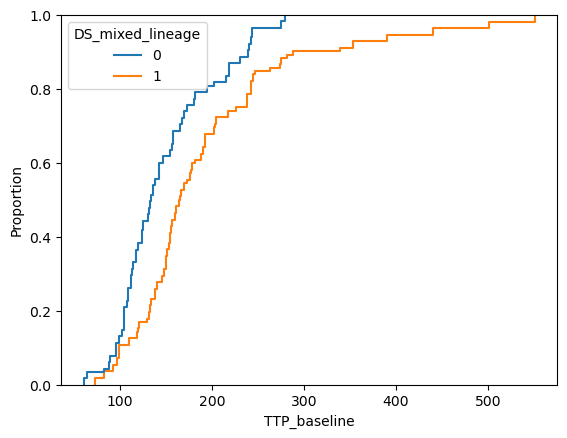

In [230]:
sns.ecdfplot(data=patient_data,
             x='TTP_baseline',
             hue='DS_mixed_lineage'
            )

In [222]:
patient_data['HIV_CD4'].value_counts()

HIV_CD4
0.0    179
1.0     37
2.0     12
Name: count, dtype: int64

In [223]:
contingency_table

DS_mixed_lineage,0,1
HIV_CD4,,
0.0,94,85
1.0,15,22
2.0,5,7


In [224]:
patient_data.groupby('HIV_CD4')[['DS_mixed_lineage', 'DS_mix_props_Shannon_entropy', 'TTP_baseline']].mean()

,DS_mixed_lineage,DS_mix_props_Shannon_entropy,TTP_baseline
HIV_CD4,,,
0.0,0.474860,0.427654,161.454545
1.0,0.594595,0.536001,193.250000
2.0,0.583333,0.428278,240.500000


In [225]:
st.mannwhitneyu(patient_data.query("HIV_CD4==0").DS_mix_props_Shannon_entropy,
                patient_data.query("HIV_CD4==1").DS_mix_props_Shannon_entropy,
                alternative='less'
               )

MannwhitneyuResult(statistic=2905.0, pvalue=0.10443073907401113)

In [226]:
st.mannwhitneyu(patient_data.query("HIV_CD4==1").DS_mix_props_Shannon_entropy,
                patient_data.query("HIV_CD4==2").DS_mix_props_Shannon_entropy,
                alternative='greater'
               )

MannwhitneyuResult(statistic=258.5, pvalue=0.1929103684116113)

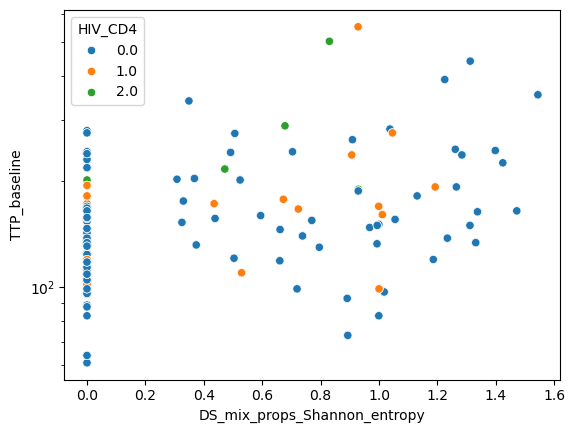

In [227]:
sns.scatterplot(data=patient_data,
                x='DS_mix_props_Shannon_entropy',
                y='TTP_baseline',
                hue='HIV_CD4',
                palette='tab10'
               )

plt.yscale('log')

In [231]:
st.fisher_exact(contingency_table[[0, 1]])

SignificanceResult(statistic=1.6219607843137256, pvalue=0.2089315645838527)

In [232]:
st.fisher_exact(contingency_table[[0, 2]])

SignificanceResult(statistic=1.5482352941176472, pvalue=0.5572886970853025)

In [233]:
st.fisher_exact(contingency_table[[1, 2]])

SignificanceResult(statistic=0.9545454545454546, pvalue=1.0)

In [95]:
patient_data.groupby('DS_mixed_lineage')['HIV_CD4'].mean()

DS_mixed_lineage
0    0.169014
1    0.297710
Name: HIV_CD4, dtype: float64

In [96]:
patient_data.groupby('HIV_CD4')['DS_mixed_lineage'].mean()

HIV_CD4
0.0    0.625000
1.0    0.696970
2.0    0.888889
Name: DS_mixed_lineage, dtype: float64

In [93]:
contingency_table

HIV_CD4,0.0,1.0,2.0
DS_mixed_lineage,,,
0,60,10,1
1,100,23,8


In [87]:
patient_data.groupby('HIV_CD4')[['n_phy', 'DS_mix_props_Shannon_entropy']].mean()

,n_phy,DS_mix_props_Shannon_entropy
HIV_CD4,,
0.0,2.106250,0.489176
1.0,2.272727,0.622672
2.0,2.555556,0.561329


In [49]:
st.spearmanr(patient_data['DS_mix_props_Shannon_entropy'],
             patient_data['TTP_baseline'],
            )

SignificanceResult(statistic=0.37420631501965373, pvalue=3.502586178257404e-05)

In [72]:
patient_data.groupby('DS_mixed_lineage')['TTP_baseline'].mean()

DS_mixed_lineage
0    139.944444
1    192.150000
Name: TTP_baseline, dtype: float64

In [450]:
st.mannwhitneyu(patient_data.query("DS_mixed_lineage==1")['TTP_baseline'].dropna(),
                patient_data.query("DS_mixed_lineage==0")['TTP_baseline'].dropna(),
                alternative='greater'
               )

MannwhitneyuResult(statistic=2453.0, pvalue=0.004618819462744727)

In [451]:
patient_data.groupby('DS_mixed_lineage')['smear_pos_no_contam_sputum_specimen_1'].mean()

DS_mixed_lineage
0.0    0.803922
1.0    0.773810
Name: smear_pos_no_contam_sputum_specimen_1, dtype: float64

In [452]:
# Create a contingency table
contingency_table = pd.crosstab(patient_data['DS_mixed_lineage'], patient_data['smear_pos_no_contam_sputum_specimen_1'])
# print(contingency_table)

# Run chi-squared test
chi2, p, dof, expected = st.chi2_contingency(contingency_table)

# print(f"Chi-squared statistic = {chi2:.4f}")
# print(f"Degrees of freedom = {dof}")
print(f"P-value = {p:.4g}")
# print("Expected counts:")
# print(expected)

P-value = 0.8439


In [151]:
st.mannwhitneyu(patient_data.query("DS_mixed_lineage==1")['smear_grade_baseline'].dropna(),
                patient_data.query("DS_mixed_lineage==0")['smear_grade_baseline'].dropna(),
                alternative='greater'
               )

MannwhitneyuResult(statistic=3490.5, pvalue=0.3841850513910086)

In [455]:
st.spearmanr(patient_data[['TTP_baseline', 'DS_F2']].dropna()['DS_F2'],
             patient_data[['TTP_baseline', 'DS_F2']].dropna()['TTP_baseline']
            )

SignificanceResult(statistic=0.49386320763035024, pvalue=8.601648147437707e-09)

In [469]:
st.spearmanr(patient_data[['TTP_baseline', 'DS_mix_props_Shannon_entropy']].dropna()['DS_mix_props_Shannon_entropy'],
             patient_data[['TTP_baseline', 'DS_mix_props_Shannon_entropy']].dropna()['TTP_baseline']
            )

SignificanceResult(statistic=0.3034538154914277, pvalue=0.0005241737626070224)

In [472]:
patient_data[['TTP_baseline', 'DS_mix_props_Shannon_entropy']].dropna()

,TTP_baseline,DS_mix_props_Shannon_entropy
0,190.0,0.754903
1,238.0,1.078796
2,239.0,-0.000000
3,146.0,0.851600
4,551.0,0.907934
...,...,...
129,290.0,0.586511
130,333.0,-0.000000
131,279.0,-0.000000
133,179.0,0.468361


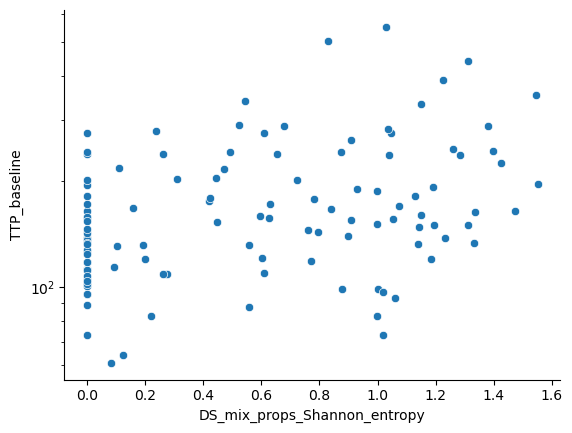

In [47]:
sns.scatterplot(data=patient_data,
                x='DS_mix_props_Shannon_entropy',
                y='TTP_baseline'
               )

plt.yscale('log')

sns.despine()
plt.show()

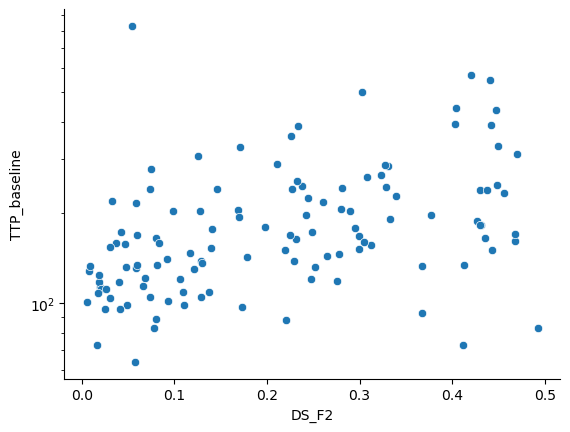

In [456]:
sns.scatterplot(data=patient_data,
                x='DS_F2',
                y='TTP_baseline'
               )

plt.yscale('log')

sns.despine()
plt.show()

<Axes: xlabel='DS_F2', ylabel='Count'>

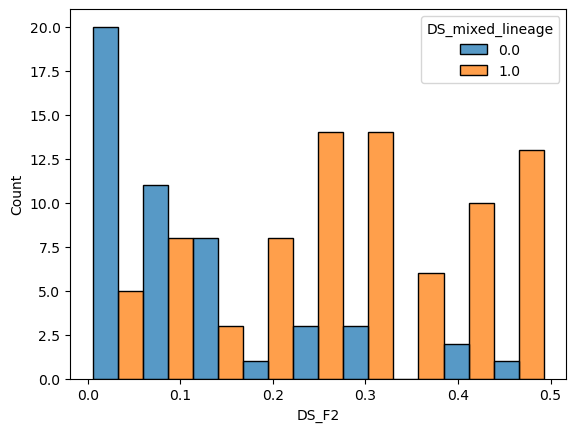

In [457]:
sns.histplot(data=patient_data,
             x='DS_F2',
             hue='DS_mixed_lineage',
             multiple='dodge'
            )

In [52]:
def fit_univariate_TCC_model(covariate, stratify_covariates):
    
    df_test_results, df_samples_imputations, cph_models_imputations = fit_cox_models_all_imputations(patient_data,
                                                                                                      patient_data,
                                                                                                       patient_data,
                                                                                                      df_imputed_TCC,
                                                                                                      [covariate] + stratify_covariates,
                                                                                                      event_col = 'culture_convert',
                                                                                                      time_col = 'TCC',
                                                                                                      exclude_resistance=False,
                                                                                                      MIC_type='none',
                                                                                                      tb_deaths_only=False,
                                                                                                      invert_OR=True,
                                                                                                      stratify_variables=stratify_covariates,
                                                                                                     # non_linear_term_variables=nonlinear_variables,
                                                                                                     )

    df_violating_covariates = []

    for model_idx in range(len(cph_models_imputations)):

        df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_models_imputations[model_idx], df_samples_imputations[model_idx], time_transform='rank').summary

        # diabetes has a p-value of like 0.0105
        violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})

        violating_covariates['imp_num'] = model_idx + 1

        df_violating_covariates.append(violating_covariates)

    df_violating_covariates = pd.concat(df_violating_covariates)
    
    df_test_results['NumViolating'] = len(df_violating_covariates.query("p <= 0.01"))

    return df_test_results

In [53]:
df_univariate_results_all = []

for covariate in ['DS_mix_props_Shannon_entropy']:
    
    if covariate not in stratify_covariates:
        print(covariate)    
        df_univariate_results_all.append(fit_univariate_TCC_model(covariate, stratify_covariates))

df_univariate_results_all = pd.concat(df_univariate_results_all)

DS_mix_props_Shannon_entropy
    116 total pids


In [54]:
df_univariate_results_all

,covariate,coef_pooled,V_w,V_b,V_t,se_pooled,riv,wald_stat,dof_old,lambda,dof_observed,dof_adj,pval,t_critical,coef_lower,coef_upper,HR_TCC_assoc,HR_TCC_assoc_lower,HR_TCC_assoc_upper,NumViolating
0,DS_mix_props_Shannon_entropy,0.161935,0.053752,0.011072,0.065193,0.255329,0.212838,0.634222,941.680715,0.175488,93.211792,84.816294,0.527643,1.98833,-0.345743,0.669614,0.850496,0.511906,1.41304,0


In [37]:
# adjusted by stratifiying for hig_lung_involvement, smear positivity, and HIV_CD4 
df_univariate_results_all.query("NumViolating != 0").sort_values('NumViolating', ascending=False)[['covariate', 'NumViolating']]

,covariate,NumViolating
0,screen_years,1


In [40]:
df_univariate_results_all.query("pval <= 0.2").sort_values('pval')[['covariate', 'pval', 'HR_TCC_assoc_lower', 'HR_TCC_assoc', 'HR_TCC_assoc_upper']]

,covariate,pval,HR_TCC_assoc_lower,HR_TCC_assoc,HR_TCC_assoc_upper
0,TTP_baseline,0.000403,0.095503,0.218634,0.500516
0,screen_years,0.004267,1.009165,1.028914,1.049050


In [41]:
df_univariate_results_all.sort_values('pval')[['covariate', 'pval', 'HR_TCC_assoc_lower', 'HR_TCC_assoc', 'HR_TCC_assoc_upper']]

,covariate,pval,HR_TCC_assoc_lower,HR_TCC_assoc,HR_TCC_assoc_upper
0,TTP_baseline,0.000403,0.095503,0.218634,0.500516
0,screen_years,0.004267,1.009165,1.028914,1.049050
0,DS_F2,0.241707,0.058167,0.346822,2.067923
0,fstrom1_baseline,0.275790,0.793535,1.330214,2.229859
0,bl_prevtb,0.322590,0.782187,1.279381,2.092617
0,screen_sex,0.422816,0.765638,1.200609,1.882693
0,inh_resistant,0.537116,0.485591,1.388113,3.968070
0,DS_mixed_lineage,0.582227,0.546548,0.876687,1.406243
0,peth_value_baseline,0.614001,0.909405,1.033090,1.173596
0,underweight,0.725198,0.684301,1.085564,1.722121


In [145]:
df_univariate_results_all.query("pval <= 0.2").sort_values('pval')[['covariate', 'pval', 'HR_TCC_assoc_lower', 'HR_TCC_assoc', 'HR_TCC_assoc_upper']]

,covariate,pval,HR_TCC_assoc_lower,HR_TCC_assoc,HR_TCC_assoc_upper
0,TTP_baseline,0.000403,0.095503,0.218634,0.500516
0,screen_years,0.004267,1.009165,1.028914,1.049050


In [154]:
df_univariate_results_all.query("covariate.str.contains('DS')").sort_values('pval')[['covariate', 'pval', 'HR_TCC_assoc_lower', 'HR_TCC_assoc', 'HR_TCC_assoc_upper']]

,covariate,pval,HR_TCC_assoc_lower,HR_TCC_assoc,HR_TCC_assoc_upper
0,DS_F2,0.241707,0.058167,0.346822,2.067923
0,DS_mixed_lineage,0.582227,0.546548,0.876687,1.406243


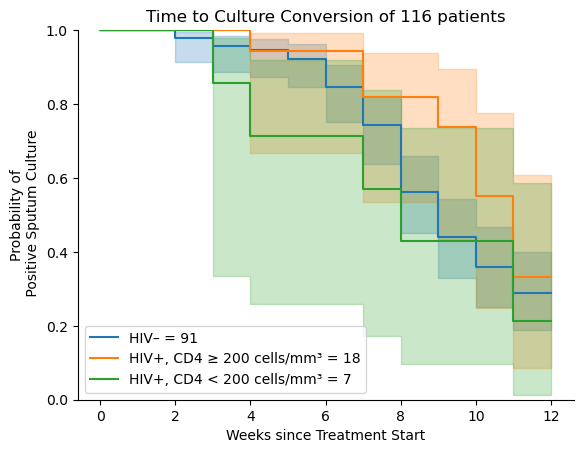

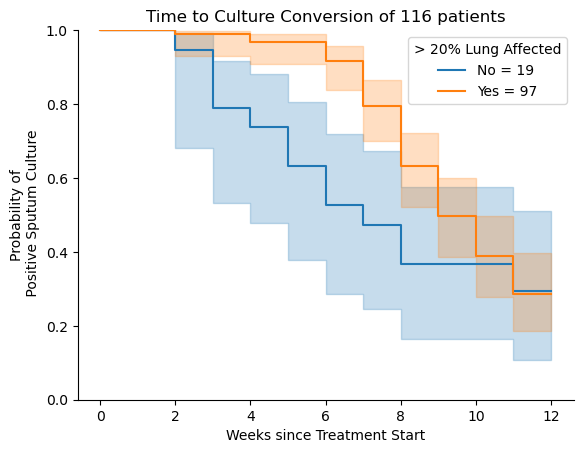

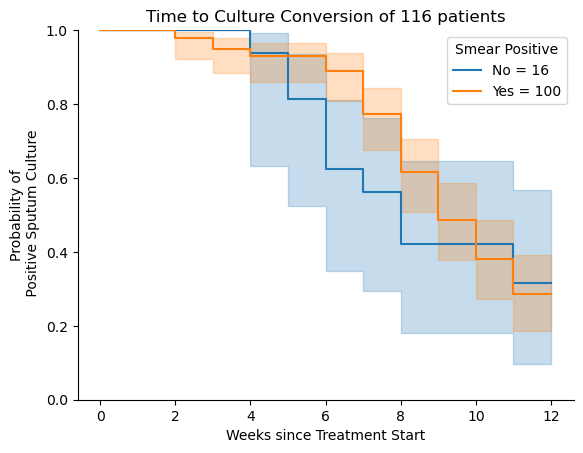

In [73]:
df_check_stratify_vars = patient_data.merge(df_TCC, on='pid')
df_check_stratify_vars['high_lung_involvement'] = (df_check_stratify_vars['predicted_PLI'] > 20)
df_check_stratify_vars['high_lung_involvement'] = df_check_stratify_vars['high_lung_involvement'].astype(int)

categorical_cols = ['HIV_CD4', 'high_lung_involvement', 'smear_pos_no_contam_sputum_specimen_1']
labels_lst = ['HIV_CD4', '> 20% Lung Affected', 'Smear Positive']

legend_name_dict = dict(zip(categorical_cols, labels_lst))

df_logrank_pvalues = pd.DataFrame(columns = ['covariate', 'pval']).set_index('covariate')

for variable in categorical_cols:
    
    fig, ax = plt.subplots()
    
    df_single_variable = df_check_stratify_vars.dropna(subset=variable)
    df_single_variable[variable] = df_single_variable[variable].astype(int)
    
    if variable == 'HIV_CD4':
        legend_marker_dict = {0: 'HIV–', 1: 'HIV+, CD4 ≥ 200 cells/mm\u00B3', 2: 'HIV+, CD4 < 200 cells/mm\u00B3'}
        color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))
    # elif variable == 'Lineage 2':
    #     legend_marker_dict = {1: 'L1', 2: 'L2', 3: 'L3', 4: 'L4'}
    #     color_dict = {1: "#DF83AC", 2: "#7098CB", 3: "#815D9F", 4: "#E76956"}
    else:
        legend_marker_dict = {0: 'No', 1: 'Yes'}
        color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

    # sort so that 0 is plotted before 1
    for group in np.sort(df_single_variable[variable].unique()):
        
        df_single_group = df_single_variable.query(f"{variable}==@group")
            
        kmf = lifelines.KaplanMeierFitter()
        kmf.fit(df_single_group['TCC'], event_observed=df_single_group['culture_convert'], label=group)
            
        kmf.plot_survival_function(ax=ax, show_censors=False, color=color_dict[group], censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, label=f"{legend_marker_dict[group]} = {len(df_single_group)}")

        if variable != 'HIV_CD4':
            plt.legend(title=legend_name_dict[variable])

    # HIV with high CD4 and HIV-negative are not significantly different, so just compare HIV with low CD4 to the other 2 groups
    if variable == 'HIV_CD4':
        
        # do them separately for each of the two HIV groups relative to the no HIV group
        logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_single_variable.query(f"{variable}==1")['TCC'], 
                                                                  durations_B=df_single_variable.query(f"{variable}==0")['TCC'], 
                                                                  event_observed_A=df_single_variable.query(f"{variable}==1")['culture_convert'], 
                                                                  event_observed_B=df_single_variable.query(f"{variable}==0")['culture_convert'],
                                                                 p = 0,
                                                                 q = 0,
                                                                 )
        
        df_logrank_pvalues.loc['HIV_High_CD4', :] = logRank_test_results.p_value
        
        logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_single_variable.query(f"{variable}==2")['TCC'], 
                                                                  durations_B=df_single_variable.query(f"{variable}==0")['TCC'], 
                                                                  event_observed_A=df_single_variable.query(f"{variable}==2")['culture_convert'], 
                                                                  event_observed_B=df_single_variable.query(f"{variable}==0")['culture_convert'],
                                                                 p = 0,
                                                                 q = 0,
                                                                 )
        
        df_logrank_pvalues.loc['HIV_Low_CD4', :] = logRank_test_results.p_value
        
    else:
        logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_single_variable.query(f"{variable}==1")['TCC'], 
                                                                  durations_B=df_single_variable.query(f"{variable}==0")['TCC'], 
                                                                  event_observed_A=df_single_variable.query(f"{variable}==1")['culture_convert'], 
                                                                  event_observed_B=df_single_variable.query(f"{variable}==0")['culture_convert'],
                                                                 p = 0,
                                                                 q = 0,
                                                                 )

    # print(f"{legend_name_dict[variable]}: χ^2 = {logRank_test_results.test_statistic}, p = {logRank_test_results.p_value}")
    plt.ylim(0, 1)

    sns.despine()
    plt.title(f"Time to Culture Conversion of {df_single_variable.pid.nunique()} patients")
    plt.ylabel("Probability of\n Positive Sputum Culture") #
    plt.xlabel("Weeks since Treatment Start")
    sns.despine()
    
    if variable != 'HIV_CD4':
        df_logrank_pvalues.loc[variable, :] = logRank_test_results.p_value
    
    if variable in stratify_covariates:
        plt.savefig(f"figures/TCC_KM_estimate_stratified_{legend_name_dict[variable]}.svg", bbox_inches='tight')
    else:
        plt.close()
    
# df_logrank_pvalues.to_csv("./model_results/TCC/KM_logRank_test_pvalues.csv")

In [74]:
df_logrank_pvalues

,pval
covariate,
HIV_High_CD4,0.249722
HIV_Low_CD4,0.57341
high_lung_involvement,0.113864
smear_pos_no_contam_sputum_specimen_1,0.494431


In [67]:
patient_data.merge(df_TCC, on='pid').groupby('smear_pos_no_contam_sputum_specimen_1').culture_convert.mean()

smear_pos_no_contam_sputum_specimen_1
0.0    0.685714
1.0    0.614035
Name: culture_convert, dtype: float64

In [69]:
patient_data.merge(df_TCC, on='pid').groupby('smear_pos_no_contam_sputum_specimen_1').TCC.mean()




smear_pos_no_contam_sputum_specimen_1
0.0    7.371429
1.0    8.298246
Name: TCC, dtype: float64

In [75]:
st.spearmanr(patient_data[['TTP_baseline', 'DS_F2']].dropna()['DS_F2'],
             patient_data[['TTP_baseline', 'DS_F2']].dropna()['TTP_baseline']
            )

SignificanceResult(statistic=0.5293895358637097, pvalue=1.5638256859315027e-10)

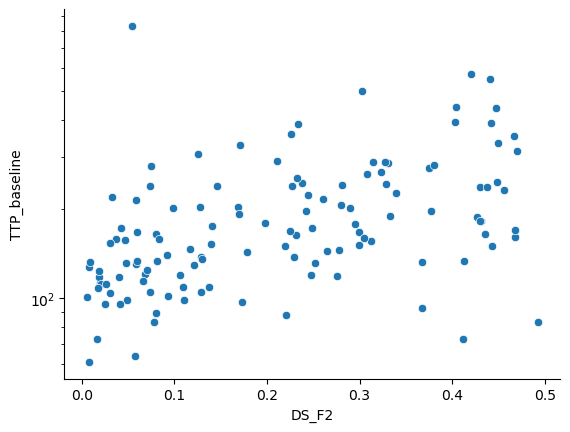

In [74]:
sns.scatterplot(data=patient_data,
                x='DS_F2',
                y='TTP_baseline'
               )

plt.yscale('log')
sns.despine()

plt.savefig("./figures/TTP_vs_DS_F2.svg", bbox_inches='tight')

<Axes: xlabel='DS_F2', ylabel='Count'>

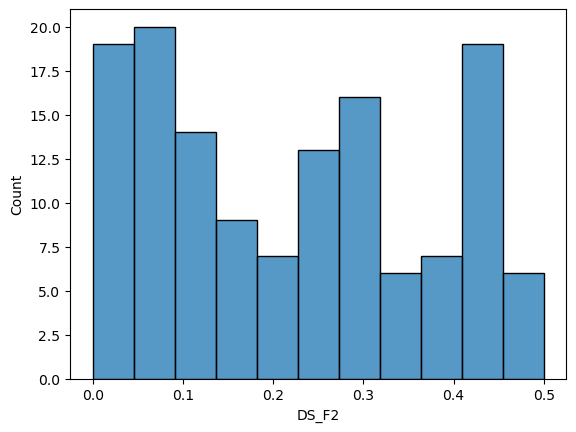

In [85]:
sns.histplot(data=patient_data,
             x='DS_F2',
             bins=np.linspace(0, 0.5, 12)
            )

In [86]:
patient_data.DS_mixed_lineage.value_counts()

DS_mixed_lineage
1    85
0    81
Name: count, dtype: int64

<Axes: xlabel='TTP_baseline', ylabel='Count'>

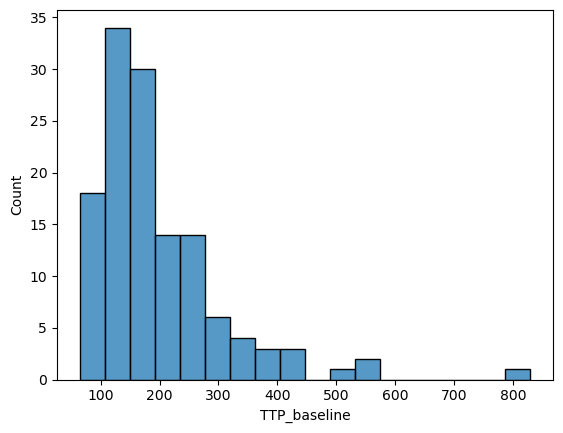

In [13]:
sns.histplot(data=patient_data,
             x='TTP_baseline'
            )

<Axes: xlabel='peth_value_baseline', ylabel='Count'>

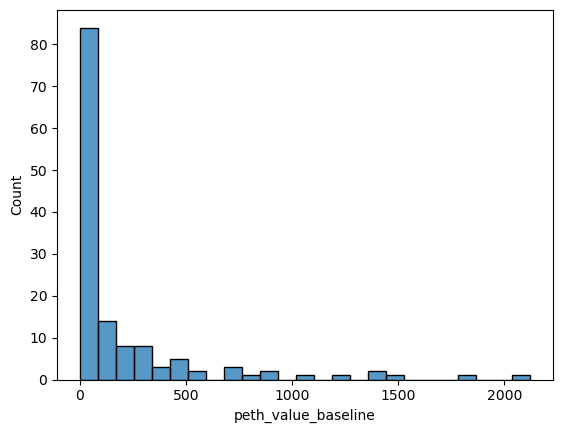

In [14]:
sns.histplot(data=patient_data,
             x='peth_value_baseline'
            )

In [57]:
cols_lst

['screen_sex',
 'screen_years',
 'underweight',
 'fstrom1_baseline',
 'smoked_substance_use',
 'peth_value_baseline',
 'HIV_CD4',
 'bl_prevtb',
 'TTP_baseline',
 'smear_pos_no_contam_sputum_specimen_1',
 'diabetes',
 'high_lung_involvement',
 'DS_mix_props_Shannon_entropy']

In [58]:
df_test_results, df_samples_imputations, cph_models_imputations = fit_cox_models_all_imputations(patient_data,
                                                                                                  patient_data,
                                                                                                   patient_data,
                                                                                                  df_imputed_TCC,
                                                                                                  cols_lst,
                                                                                                  event_col = 'culture_convert',
                                                                                                  time_col = 'TCC',
                                                                                                  exclude_resistance=False,
                                                                                                  MIC_type='none',
                                                                                                  tb_deaths_only=False,
                                                                                                  invert_OR=True,
                                                                                                  stratify_variables=stratify_covariates,
                                                                                                 # non_linear_term_variables=nonlinear_variables,
                                                                                                 binary_lineage=True
                                                                                                 )

    114 total pids


In [59]:
df_violating_covariates = []

for model_idx in range(len(cph_models_imputations)):

    df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_models_imputations[model_idx], df_samples_imputations[model_idx], time_transform='rank').summary

    # diabetes has a p-value of like 0.0105
    violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})
    
    violating_covariates['imp_num'] = model_idx + 1

    df_violating_covariates.append(violating_covariates)

df_violating_covariates = pd.concat(df_violating_covariates)

In [61]:
df_violating_covariates.query("p <= 0.05").covariate.value_counts()

covariate
diabetes                11
screen_years             6
smoked_substance_use     1
Name: count, dtype: int64

In [62]:
df_test_results.query("pval <= 0.05")

,covariate,coef_pooled,V_w,V_b,V_t,se_pooled,riv,wald_stat,dof_old,lambda,dof_observed,dof_adj,pval,t_critical,coef_lower,coef_upper,HR_TCC_assoc,HR_TCC_assoc_lower,HR_TCC_assoc_upper
1,TTP_baseline,1.839765,0.25099,0.060435,0.313439,0.559857,0.248812,3.286136,730.550762,0.199239,83.323249,74.792735,0.001548,1.992193,0.724423,2.955107,0.158855,0.052073,0.484604


In [63]:
df_test_results

,covariate,coef_pooled,V_w,V_b,V_t,se_pooled,riv,wald_stat,dof_old,lambda,dof_observed,dof_adj,pval,t_critical,coef_lower,coef_upper,HR_TCC_assoc,HR_TCC_assoc_lower,HR_TCC_assoc_upper
0,DS_mix_props_Shannon_entropy,-0.053398,0.084094,0.030681,0.115797,0.340290,0.376998,-0.156920,386.889421,0.273782,75.566603,63.218809,0.875808,1.998205,-0.733367,0.626570,1.054850,0.534422,2.082079
1,TTP_baseline,1.839765,0.250990,0.060435,0.313439,0.559857,0.248812,3.286136,730.550762,0.199239,83.323249,74.792735,0.001548,1.992193,0.724423,2.955107,0.158855,0.052073,0.484604
2,bl_prevtb,-0.092100,0.070028,0.026750,0.097670,0.312522,0.394729,-0.294699,362.059453,0.283015,74.605934,61.859228,0.769210,1.999062,-0.716851,0.532651,1.096475,0.587047,2.047974
3,diabetes,-0.096861,0.329617,0.117900,0.451447,0.671898,0.369610,-0.144160,398.202812,0.269865,75.974213,63.801373,0.885829,1.997849,-1.439211,1.245490,1.101707,0.287800,4.217368
4,fstrom1_baseline,0.041234,0.101473,0.026573,0.128932,0.359071,0.270603,0.114836,639.370202,0.212972,81.894220,72.595739,0.908892,1.993184,-0.674461,0.756930,0.959604,0.469105,1.962974
5,peth_value_baseline,-0.034253,0.005713,0.002042,0.007822,0.088443,0.369319,-0.387290,398.661241,0.269710,75.990363,63.824524,0.699830,1.997835,-0.210949,0.142442,1.034847,0.867238,1.234849
6,screen_sex,-0.140029,0.082156,0.021500,0.104374,0.323069,0.270424,-0.433434,640.037147,0.212861,81.905769,72.613407,0.665984,1.993176,-0.783963,0.503904,1.150307,0.604167,2.190134
7,screen_years,-0.027170,0.000154,0.000034,0.000189,0.013762,0.229467,-1.974242,832.510632,0.186640,84.634240,76.824182,0.051949,1.991327,-0.054575,0.000235,1.027542,0.999765,1.056091
8,smoked_substance_use,0.086851,0.097618,0.025809,0.124287,0.352544,0.273202,0.246355,629.831945,0.214579,81.727047,72.340179,0.806105,1.993303,-0.615876,0.789578,0.916814,0.454037,1.851277
9,underweight,0.026293,0.078009,0.023084,0.101863,0.319160,0.305782,0.082381,528.829537,0.234175,79.687921,69.252452,0.934582,1.994816,-0.610373,0.662958,0.974050,0.515325,1.841118


In [140]:
labels_dict = {'RIF_AUC': 'Rifampicin PK AUC',
              'INH_AUC': 'Isoniazid PK AUC',
              'EMB_AUC': 'Ethambutol PK AUC',
              'PZA_AUC': 'Pyrazinamide PK AUC',
              'screen_sex': 'Male Sex',
              'screen_years': 'Age',
              'bl_bmi': 'Body Mass Index',
              'smoked_substance_use': 'Smoked Substance Use',
              'HIV_High_CD4': 'HIV, CD4 ≥ 200 cells/$\mathregular{mm^3}$',
              'HIV_Low_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$',
              'bl_prevtb': 'Previous TB Disease',
              'smear_pos_no_contam_sputum_specimen_1': 'Smear Positivity at Baseline',
              'diabetes': 'Diabetes',
              'Lineage_1': 'Lineage 1',
              'Lineage_2': 'Lineage 2',
              'Lineage_3': 'Lineage 3',
              'Lineage_4': 'Lineage 4',
              'total_adherence': 'Adherence Rate',
              'F2': 'F2 Strain Mixing Metric',
              'inh_resistant': 'INH Resistant',
              'high_lung_involvement': '>20% Lung Affected',
              'RIF_pred_MIC': 'Predicted RIF MIC',
              'INH_pred_MIC': 'Predicted INH MIC',
              'EMB_pred_MIC': 'Predicted EMB MIC',
              'PZA_pred_MIC': 'Predicted PZA MIC',
              'RIF_midpoint': 'Measured RIF MIC',
              'INH_midpoint': 'Measured INH MIC',
              'EMB_midpoint': 'Measured EMB MIC',
              'PZA_midpoint': 'Measured PZA MIC',
               'delayed_TCC': 'TCC > 8 Weeks',
               'TTP_baseline': 'TTP at Baseline',
               'peth_value_baseline': 'PEth',
               'fstrom1_baseline': 'Smoking',
               'RIF_pred_MIC_high': 'Predicted RIF MIC > 0.06 µg/mL',
               # 'INH_pred_MIC_high': 'Predicted Isoniazid MIC',
               'PZA_pred_MIC_high': 'Predicted Pyrazinamide MIC > 24.6 µg/mL',
               'HIV_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$', # when we computed the relative risk, it was this group vs. the other two groups,
               'high_lung_involvement': 'PLI > 20%',
               'Not_Lineage_2': 'Not Lineage 2',
               'NumVar': '# of low-AF Segregating Sites',
               'NumVar1': '# of low-AF Sites at Baseline',
               'ChangeSites': '# of low-AF Sites with a Change',
               'underweight': 'BMI < 18',
               'DS_mixed_lineage': 'DS Mixed Lineage',
               'DS_F2': 'F2 Direct from Sputum'
             }

In [141]:
forest_plot(df_test_results.sort_values('pval')[['covariate', 'pval', 'HR_TCC_assoc_lower', 'HR_TCC_assoc', 'HR_TCC_assoc_upper']],
            df_test_results.sort_values('pval').covariate.values,
            labels_dict,
            val_col='HR_TCC_assoc',
            # pval_offset=2
            saveName="./figures/TCC_multivariate_DS_Mixed_Lineage.svg"
           )